In [29]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [ ]:
# Upload file zip dataset
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [31]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset berhasil diekstrak")

Dataset berhasil diekstrak


In [32]:
import os

os.listdir('dataset')

['Font Dataset Large', 'Font Dataset Large Color']

In [33]:
os.listdir('dataset/Font Dataset Large')

['Cambria',
 'Georgia',
 'Calvin',
 'Bembo',
 'Lucida Bright',
 'Arial',
 'Frutiger',
 'Myriad',
 'Rockwell',
 'Agency',
 'Garamond',
 'Elephant',
 'Hombre',
 'Perpetua',
 'Franklin Gothic',
 'Palatino linotype',
 'Consolas',
 'Book Antiqua',
 'Fascinate',
 'Snowdrift Regular',
 'Calligraphy',
 'Corbel',
 'Akzidenz Grotesk',
 'Bodoni',
 'Candara',
 'Futura',
 'Sabon',
 'Verdana',
 'Century',
 'Brandish',
 'Californian FB',
 'Calibry',
 'LCD Mono',
 'Algerian',
 'Bell MT',
 'Steppes TT',
 'Mrs Eaves',
 'Gill sans',
 'Comic Sans MS',
 'Baskerville',
 'Minion',
 'News Gothic',
 'Courier',
 'Helvetica',
 'Nasalization',
 'Monotype Corsiva',
 'Times New Roman',
 'Didot']

In [34]:
train_dir = 'dataset/Font Dataset Large'

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [36]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [37]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 192000 images belonging to 48 classes.


In [38]:
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 48000 images belonging to 48 classes.


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_generator.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         6,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,392 (2.63 MB)

 Trainable params: 689,392 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

train_generator.samples = 2000

Found 192000 images belonging to 48 classes.


In [46]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)

Epoch 1/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1970s 328ms/step - accuracy: 0.5674 - loss: 1.2622 - val_accuracy: 0.7601 - val_loss: 0.7424
Epoch 2/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1902s 317ms/step - accuracy: 0.6687 - loss: 0.9692 - val_accuracy: 0.8460 - val_loss: 0.5002
Epoch 3/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1898s 316ms/step - accuracy: 0.7285 - loss: 0.7925 - val_accuracy: 0.8738 - val_loss: 0.3998


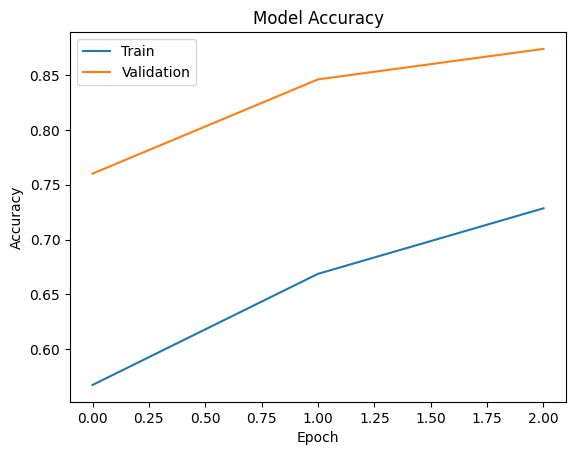

In [47]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

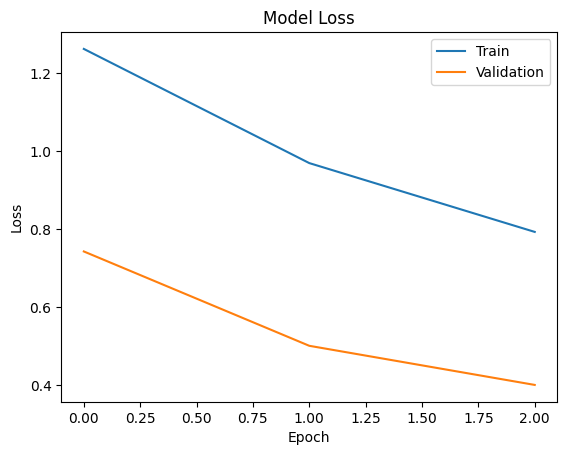

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [49]:
loss, accuracy = model.evaluate(validation_generator)

print("Loss :", loss)
print("Accuracy :", accuracy)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 183s 122ms/step - accuracy: 0.8710 - loss: 0.4005
Loss : 0.40054503083229065
Accuracy : 0.8709791898727417


In [50]:
import numpy as np

predictions = model.predict(validation_generator)

print(predictions)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 183s 122ms/step
[[9.49062936e-28 2.03772390e-21 0.00000000e+00 ... 5.83193053e-34
  3.01635292e-30 1.37015732e-10]
 [5.51592023e-14 2.39324197e-02 8.35764791e-11 ... 2.57749599e-10
  5.15719567e-18 3.59638985e-11]
 [1.12454279e-09 4.37230665e-05 9.80921733e-11 ... 1.28304344e-25
  5.06346005e-08 1.29359137e-06]
 ...
 [4.67286291e-14 0.00000000e+00 4.22421282e-22 ... 0.00000000e+00
  2.21798302e-07 1.59312075e-34]
 [3.10236396e-06 5.45895716e-07 1.47862628e-14 ... 3.11880282e-18
  2.60479105e-09 7.27672250e-06]
 [1.84819549e-09 5.16890182e-38 1.04075004e-16 ... 0.00000000e+00
  1.61493709e-03 4.61274618e-28]]


In [51]:
predicted_class = np.argmax(predictions[0])

print("Predicted Class :", predicted_class)

Predicted Class : 12


In [52]:
model.save('font_recognition_model.h5')

print("Model berhasil disimpan")

Model berhasil disimpan


In [53]:
from google.colab import files

files.download('font_recognition_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>